# Classifier test

In [89]:
import torch
from torchvision.io import ImageReadMode, read_image
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from tqdm.auto import tqdm

from dataclasses import dataclass
import pickle

import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
STYLEGAN2_DIR = PROJECT_DIR / 'stylegan2'
if str(STYLEGAN2_DIR) not in sys.path:
    sys.path.insert(0, str(STYLEGAN2_DIR))

from stylegan2 import *
from stylegan2.torch_utils.misc import get_device

from classifier import CelebADataset, Classifier

In [90]:
SEED = 42
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

ATTRIBUTES = ["Eyeglasses", "Male", "Young"]
DATASET_PATH = Path("dataset/celeba")
MODEL_PATH = Path("models/classifier.pt")

device = get_device()
print(device)

mps


In [91]:
classifier = Classifier(output_size=len(ATTRIBUTES))
checkpoint = torch.load(MODEL_PATH, map_location=device)
_ = classifier.load_state_dict(checkpoint)
classifier = classifier.to(device)
_ = classifier.eval()

In [92]:
dataset = CelebADataset(
    DATASET_PATH,
    used_attributes=ATTRIBUTES,
    transform=classifier.transform,
)

sample_indices = torch.randperm(len(dataset))[:16].tolist()
image_paths = [dataset.images[index] for index in sample_indices]
samples = [dataset[index] for index in sample_indices]
images = torch.stack([sample[0] for sample in samples])
labels = torch.stack([sample[1] for sample in samples])

with torch.no_grad():
    logits = classifier(images.to(device))
    probabilities = torch.sigmoid(logits).cpu()
    predictions = (probabilities >= 0.5).float()

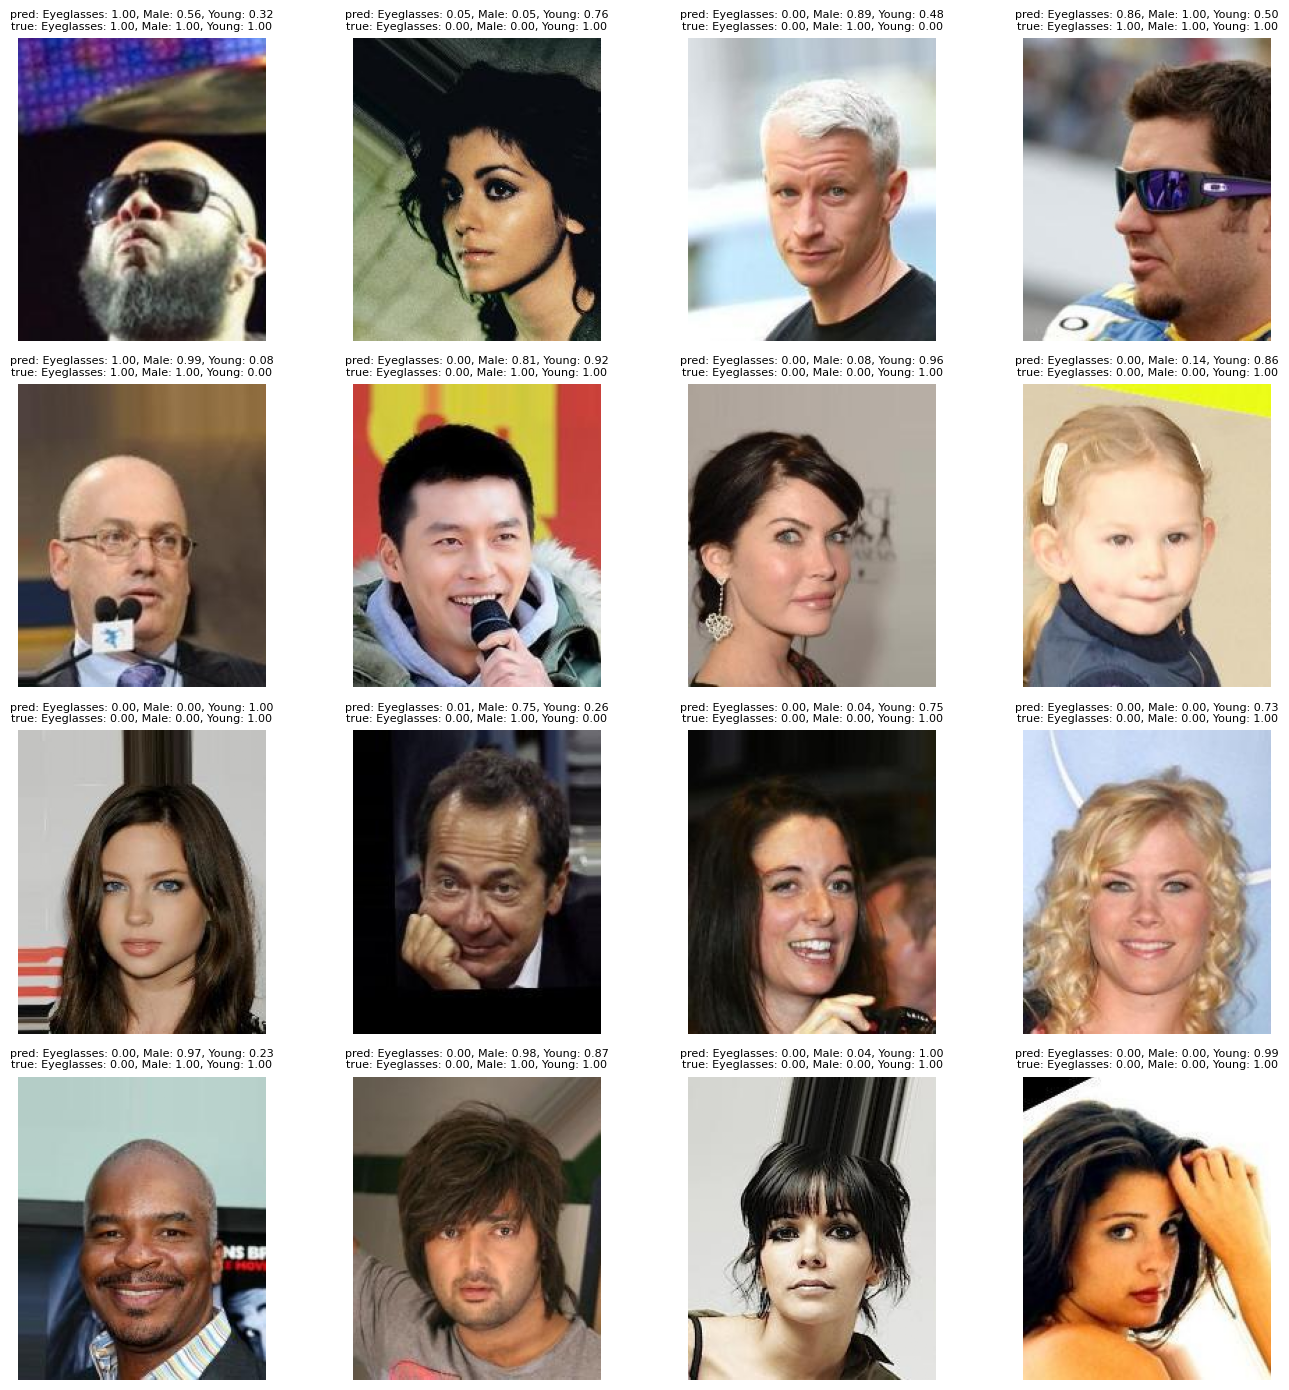

In [93]:
def format_attributes(values):
    return ", ".join(
        f"{name}: {value:.2f}" for name, value in zip(ATTRIBUTES, values.tolist())
    )

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.flatten()

for ax, image_path, probs, target in zip(axes, image_paths, probabilities, labels):
    raw_img = read_image(str(image_path), mode=ImageReadMode.RGB)
    raw_img = raw_img.permute(1, 2, 0).float() / 255.0
    ax.imshow(raw_img)
    ax.axis("off")
    ax.set_title(
        f"pred: {format_attributes(probs)}\ntrue: {format_attributes(target)}",
        fontsize=8,
    )

plt.tight_layout()

In [94]:
correct = (predictions == labels).float()
attribute_accuracy = correct.mean(dim=0)
batch_accuracy = correct.mean()

for name, acc in zip(ATTRIBUTES, attribute_accuracy.tolist()):
    print(f"{name}: {acc:.3f}")
print(f"batch mean: {batch_accuracy.item():.3f}")

Eyeglasses: 1.000
Male: 1.000
Young: 0.875
batch mean: 0.958
